In [8]:
import os

# Create folders in Drive
os.makedirs('/content/drive/MyDrive/CAPSTONE_DATA/youtube/', exist_ok=True)
os.makedirs('/content/drive/MyDrive/CAPSTONE_DATA/twitter/', exist_ok=True)
os.makedirs('/content/drive/MyDrive/CAPSTONE_DATA/reddit/', exist_ok=True)

print("✅ Folders created in Google Drive!")
print("\nNow upload your CSV files to these folders:")
print("- Go to Google Drive")
print("- Navigate to CAPSTONE_DATA/youtube/")
print("- Upload: final_youtube_comments_clean.csv")
print("- Upload: final_youtube_channels_clean.csv")
print("- Upload: final_youtube_videos_clean.csv")
print("\nDo the same for twitter/ and reddit/ folders!")

✅ Folders created in Google Drive!

Now upload your CSV files to these folders:
- Go to Google Drive
- Navigate to CAPSTONE_DATA/youtube/
- Upload: final_youtube_comments_clean.csv
- Upload: final_youtube_channels_clean.csv
- Upload: final_youtube_videos_clean.csv

Do the same for twitter/ and reddit/ folders!


In [17]:
import os

print("📂 Files in CAPSTONE_DATA:")
print("\nYouTube:")
print(os.listdir('/content/drive/MyDrive/CAPSTONE_DATA/youtube/'))
print("\nTwitter:")
print(os.listdir('/content/drive/MyDrive/CAPSTONE_DATA/twitter/'))
print("\nReddit:")
print(os.listdir('/content/drive/MyDrive/CAPSTONE_DATA/reddit/'))


📂 Files in CAPSTONE_DATA:

YouTube:
['final_youtube_comments_clean.csv', 'final_youtube_videos_clean.csv', 'final_youtube_channels_clean.csv']

Twitter:
['final_twitter_matched.csv', 'twitter_matched_users.csv', 'twitter_brand_profiles.csv', 'twitter_sponsorship_events.csv', 'final_twitter_brands.csv']

Reddit:
['final_reddit_posts.csv']


In [18]:
!pip install vaderSentiment pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.8 MB/s eta 0:00:00


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
print(" All imports done!")

 All imports done!


In [21]:
df = pd.read_csv('/content/drive/MyDrive/CAPSTONE_DATA/youtube/final_youtube_comments_clean.csv')
print(f"Shape: {df.shape}")
print(df[['comment_id', 'video_id', 'text', 'published_at']].head())

Shape: (27299, 11)
                   comment_id     video_id  \
0  UgwQY1lZFAnFtYi_2BJ4AaABAg  sbKGDTPtnmg   
1  Ugx7RlJVCCiP4ZKeY354AaABAg  sbKGDTPtnmg   
2  Ugzf3QShVOGhIJri7kh4AaABAg  I456rYvMIwA   
3  UgyDmx5aquTi0mc3feJ4AaABAg  I456rYvMIwA   
4  Ugwe95q6U0xw1sH03dR4AaABAg  aQJGFf9Y4Bo   

                                                text  \
0                                        Wow wow wow   
1                              Amazing both of you ❤   
2                                            When? ❤   
3  Am not able to see ur other member only videos...   
4  Will there still be YouTube content? At least ...   

                published_at  
0  2025-09-18 09:52:18+00:00  
1  2025-09-18 13:45:32+00:00  
2  2025-09-20 12:54:45+00:00  
3  2025-09-20 13:28:33+00:00  
4  2025-09-22 14:25:19+00:00  


In [22]:
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != '']
df['text'] = df['text'].astype(str)
print(f" Clean rows: {len(df)}")

 Clean rows: 27299


In [23]:
def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        label = 'positive'
    elif compound <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'
    return pd.Series([compound, label, scores['pos'], scores['neg'], scores['neu']])

df[['compound', 'sentiment', 'pos', 'neg', 'neu']] = df['text'].apply(get_sentiment)
print(" Sentiment done!")
print(df[['text', 'compound', 'sentiment']].head(10))

 Sentiment done!
                                                text  compound sentiment
0                                        Wow wow wow    0.9081  positive
1                              Amazing both of you ❤    0.8402  positive
2                                            When? ❤    0.6369  positive
3  Am not able to see ur other member only videos...    0.4588  positive
4  Will there still be YouTube content? At least ...    0.0000   neutral
5  Congrats Heather! Been following your workouts...    0.9289  positive
6                      100% love and support this❤❤❤    0.9661  positive
7  Heather you are the best, always enjoy your wo...    0.9468  positive
8  Im so happy for this!!! 5 years with you!!!!! ...    0.9295  positive
9                 Whoooop! So excited!❤❤❤ thank you!    0.9635  positive


In [24]:
print("=== Sentiment Distribution ===")
print(df['sentiment'].value_counts())
print(f"\nAverage compound score: {df['compound'].mean():.3f}")

=== Sentiment Distribution ===
sentiment
positive    17676
neutral      7117
negative     2506
Name: count, dtype: int64

Average compound score: 0.404


In [27]:
import os
os.makedirs('/content/drive/MyDrive/CAPSTONE_DATA/outputs', exist_ok=True)
print(" Outputs folder created!")

 Outputs folder created!


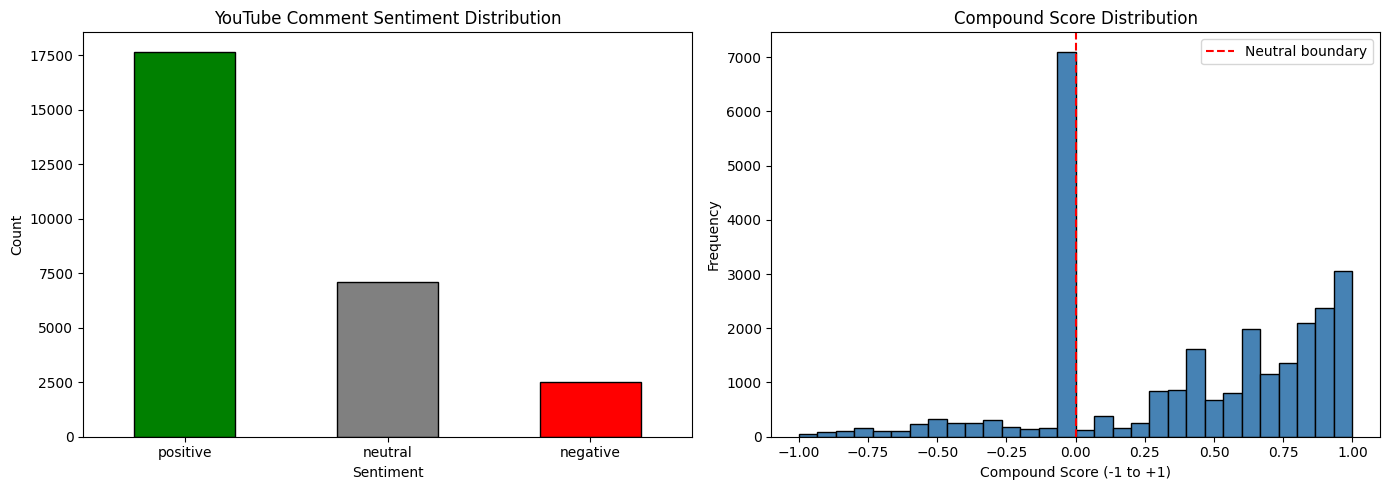

✅ Plot saved!


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Distribution
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0],
    color=['green', 'gray', 'red'], edgecolor='black')
axes[0].set_title('YouTube Comment Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2 - Compound score histogram
axes[1].hist(df['compound'], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Compound Score Distribution')
axes[1].set_xlabel('Compound Score (-1 to +1)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=0, color='red', linestyle='--', label='Neutral boundary')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CAPSTONE_DATA/outputs/youtube_sentiment_plot.png')
plt.show()
print("✅ Plot saved!")

In [30]:
import os
os.makedirs('/content/drive/MyDrive/CAPSTONE_DATA/outputs', exist_ok=True)

output_cols = ['comment_id', 'video_id', 'text', 'published_at',
               'date', 'hour', 'compound', 'sentiment', 'pos', 'neg', 'neu']
df[output_cols].to_csv(
    '/content/drive/MyDrive/CAPSTONE_DATA/outputs/youtube_comments_with_sentiment.csv',
    index=False
)
print(f" Saved! Shape: {df.shape}")
print(df['sentiment'].value_counts())

 Saved! Shape: (27299, 16)
sentiment
positive    17676
neutral      7117
negative     2506
Name: count, dtype: int64
